# *Optional* - Test your image processing functions with real images

This notebook will allow you to load images from your computer into python and use your lab7 functions to apply kernel filters and detect corners.

Note that this component of the lab is for fun and completely optional and will not impact grading.  

In [1]:
# running this cell will install the pillow package which you will need to load and display images using your program
!pip install pillow matplotlib

The cell below defines two functions:
1. `image_to_pixels`
2. `display_image`

The `image_to_pixels` function will load an image specified by a filename (string) and return a three-element tuple. The first element is a tuple of RGB pixels, the second element is the width of the image in pixels, and the third element is the height of the image in pixels. 

The `display_image` function can be used to display and optionally save a list of pixels as an image. The first argument passed to this function is a tuple of pixels, the second argument is the width of the image in pixels, and the third argument is the height of the image in pixels. You may additionally pass two optional parameters. The first, markers, is a tuple of pixel coordinates. If markers are passed to the function, red circles will be added to the image at that coordinate location. The second optional parameter, filename, is a string. If a filename is passed to the function, it will save the image to a file with the specified name. 


In [2]:
from PIL import Image, ImageDraw
from matplotlib import pyplot as plt
%matplotlib inline

def image_to_pixels(filename):
    """
    (str) -> tuple
    
    Load an image using PIL.Image and extract and return
    the pixels, width, and height as a list.
    """
    # open the image file
    img = Image.open(filename)
    
    # extract the data and put into the format described in the lab pdf
    pixels = img.getdata()
    if (isinstance(pixels[0], tuple)):
        # RGB, convert to lists
        pixels = tuple([rgb_pixel[0:3] for rgb_pixel in pixels])
    else:
        # grayscale, spoof RGB
        pixels = tuple([(pixel,pixel,pixel) for pixel in pixels])
    
    width, height = img.size
    
    return pixels, width, height

def display_image(pixels, width, height, markers=None, filename=None):
    """
    (tuple, int, int, list, str) -> None
    
    Display a tuple of pixels as an image. If markers are provided, draw
    red circles around each 2D coordinate given. If filename given,
    save generated image to file.
    """
    
    # convert to PIL image format
    rgb_img = isinstance(pixels[0],tuple)
    if rgb_img:
        img = Image.new('RGB',(width,height))
        p = pixels
    else:
        img = Image.new('L', (width,height))
        pixels = [min(int(abs(p)),255) for p in pixels]
        p = tuple(pixels)
    
    img.putdata(p)
    
    # Draw markers on the imaage
    if markers is not None:
        draw = ImageDraw.Draw(img)
        rad = max(max(width,height) // 50, 1)
        for marker in markers:
            tl = (marker[0]-rad, marker[1]-rad)
            lr = (marker[0]+rad, marker[1]+rad)
            draw.ellipse(tl + lr, outline='red' )
    
    # display the image
    if rgb_img:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()
    
    # save the image, as needed
    if filename != None:
        img.save(filename)

In [ ]:
# This cell will import the functions from your lab7.py file so we can use them in the notebook
# make sure that lab7.py is saved in the same folder as this notebook
from lab7 import convert_rgb_to_gs, kernel_filter, non_maxima_suppression, harris_corners

## Load and display an image
Try your code with your own images! Note that any images you want to display should be saved in the same folder as this notebook.

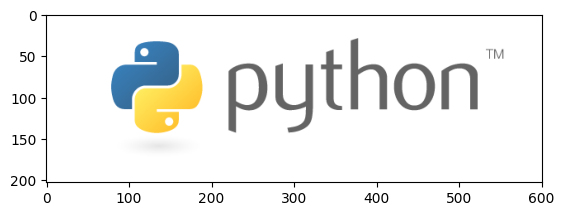

In [4]:
# load an image of the python logo
img_filename = 'python_logo.png' # change this to the name of a file you want to load
img_data = image_to_pixels(img_filename)

# extract the pixels, width, and height from the returned tuple
img = img_data[0]
width = img_data[1]
height = img_data[2]

# display the image
display_image(img, width, height)

## Convert to grayscale
The cell below will convert your image to grayscale (black and white).

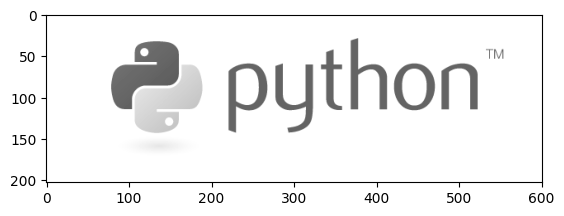

In [5]:
# convert to grayscale and display image
gs_img = convert_rgb_to_gs(img)

# display the grayscale image
display_image(gs_img, width, height)

## Apply some filters
The cells below will apply various different kernel filters to the images.

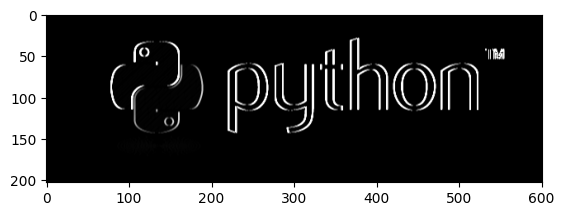

In [6]:
# apply some filters to the data

# vertical edge detection
kernel = [[-1, 0, 1],
          [-2, 0, 2],
          [-1, 0, 1]]

filt_img = kernel_filter(kernel, gs_img, width, height)
display_image(filt_img, width, height)

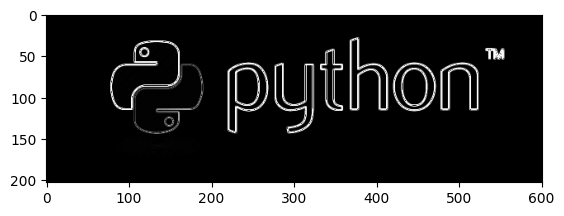

In [7]:
# outline
kernel = [[-1, -1, -1],
          [-1, 8, -1],
          [-1, -1, -1]]

filt_img = kernel_filter(kernel, gs_img, width, height)
display_image(filt_img, width, height)

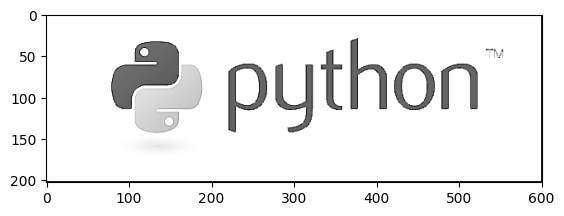

In [8]:
# sharpen
kernel = [[0, -1, 0],
          [-1, 5, -1],
          [0, -1, 0]]

filt_img = kernel_filter(kernel, gs_img, width, height)
display_image(filt_img, width, height)

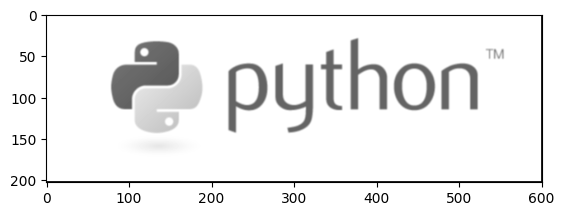

In [9]:
# gaussian blur
kernel = [[1/16, 1/8, 1/16],
          [1/8, 1/4, 1/8],
          [1/16, 1/8, 1/16]]

filt_img = kernel_filter(kernel, gs_img, width, height)
display_image(filt_img, width, height)

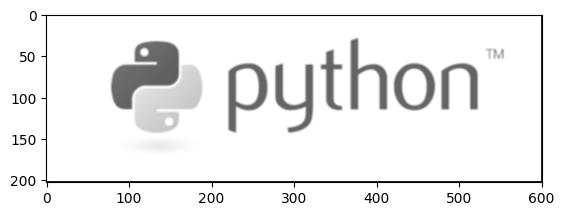

In [10]:
# box blur
kernel = [[1/9, 1/9, 1/9],
          [1/9, 1/9, 1/9],
          [1/9, 1/9, 1/9]]

filt_img = kernel_filter(kernel, gs_img, width, height)
display_image(filt_img, width, height)

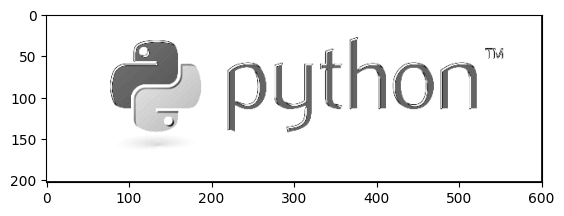

In [11]:
# emboss
kernel = [[-2, -1, 0],
          [-1, 1, 1],
          [0, 1, 2]]

filt_img = kernel_filter(kernel, gs_img, width, height)
display_image(filt_img, width, height)

## Detect corners
The cell below will run the harris corner detection and non-maxima suppression functions. Two images will be displayed: the first will be the image with all the corners returned by `harris_corners` and the second will be the image with only the corners remaining after the `non_maxima_suppression` function is applied. Corners are indicated in the displayed images by red circles.

You can try adjusting the `corner_threshold` and `min_distance` values to see how those impact the results!

Image with corners before non-maxima suppression:


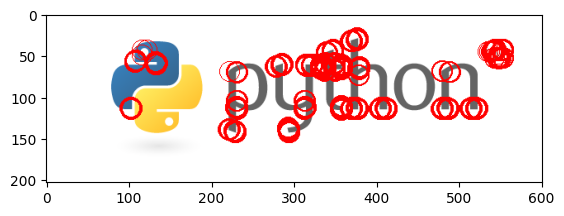

Image with corners after non-maxima suppression:


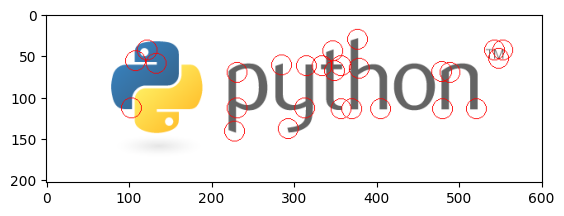

In [12]:
# detect corners
corner_threshold = 0.01
corners = harris_corners(gs_img, width, height, corner_threshold)

# Image with corners before non-maxima suppression
print("Image with corners before non-maxima suppression:")
display_image(img, width, height, corners)

# Image with corners after non-maxima suppression
min_distance = 10
non_maxima_suppressed_corners = non_maxima_suppression(corners, min_distance)
print("Image with corners after non-maxima suppression:")
display_image(img, width, height, non_maxima_suppressed_corners)